In [1]:
# Part 2 — Eigenfaces

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# Load the LFW dataset
lfw_people = fetch_lfw_people(
    min_faces_per_person=70,
    resize=0.4
)

# Get image dimensions
n_samples, h, w = lfw_people.images.shape

# Flattened image data
X = lfw_people.data
n_features = X.shape[1]

# Labels
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print("Total dataset size:")
print(" n_samples:", n_samples)
print(" n_features:", n_features)
print(" n_classes:", n_classes)
print(" image size:", h, "x", w)

Total dataset size:
 n_samples: 1288
 n_features: 1850
 n_classes: 7
 image size: 50 x 37


In [2]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# Calculate the mean face using only the training data
mean = np.mean(X_train, axis=0)

# Centre both training and testing data
X_train = X_train - mean
X_test = X_test - mean

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Mean face shape:", mean.shape)

Training data shape: (966, 1850)
Testing data shape: (322, 1850)
Mean face shape: (1850,)


In [3]:
# Perform PCA using Singular Value Decomposition (SVD)

n_components = 150

U, S, Vt = np.linalg.svd(X_train, full_matrices=False)

# Keep the first 150 principal components
components = Vt[:n_components]

# Convert the principal components into eigenface images
eigenfaces = components.reshape((n_components, h, w))

# Project training and testing data into PCA space
X_train_pca = np.dot(X_train, components.T)
X_test_pca = np.dot(X_test, components.T)

print("Number of components:", n_components)
print("Components shape:", components.shape)
print("Eigenfaces shape:", eigenfaces.shape)
print("Training PCA shape:", X_train_pca.shape)
print("Testing PCA shape:", X_test_pca.shape)

Number of components: 150
Components shape: (150, 1850)
Eigenfaces shape: (150, 50, 37)
Training PCA shape: (966, 150)
Testing PCA shape: (322, 150)


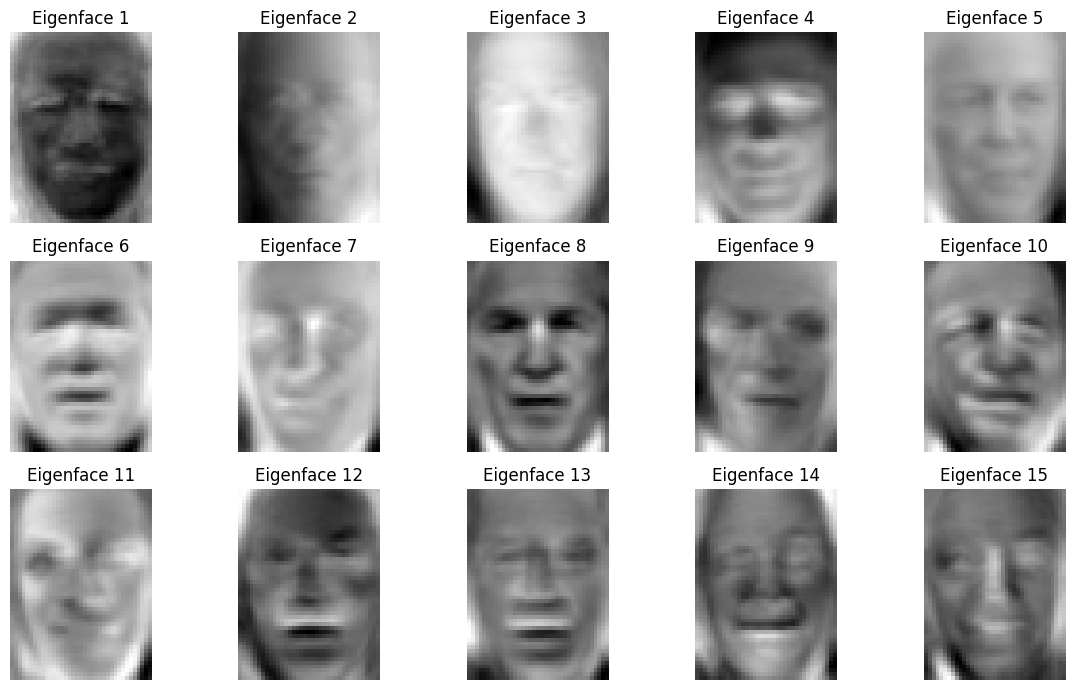

In [4]:
# Display the first 15 eigenfaces

fig, axes = plt.subplots(3, 5, figsize=(12, 7))

for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap="gray")
    ax.set_title(f"Eigenface {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

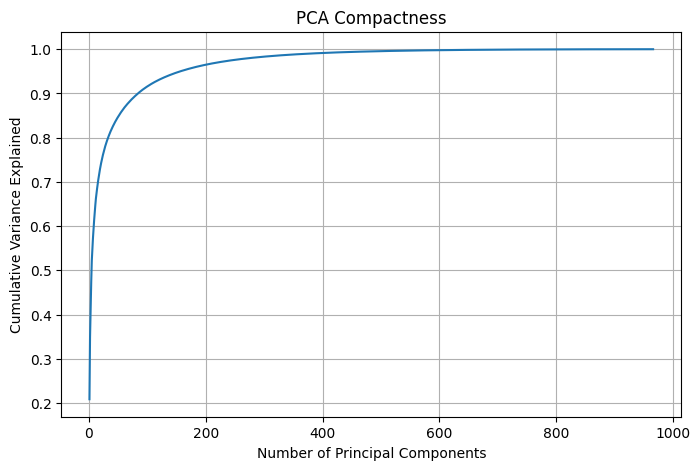

In [5]:
# Calculate the variance explained by each principal component

explained_variance = (S ** 2) / np.sum(S ** 2)
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance explained
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Compactness")
plt.grid()
plt.show()

In [8]:
# Part 2 — Random Forest classification

from sklearn.ensemble import RandomForestClassifier

# Build the Random Forest classifier
estimator = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    max_features=150,
    random_state=42
)

# Train the classifier using the PCA face space
estimator.fit(X_train_pca, y_train)

# Predict the test set
predictions = estimator.predict(X_test_pca)

# Calculate accuracy
correct = predictions == y_test
total_test = len(X_test_pca)

print("Total Testing:", total_test)
print("Total Correct:", np.sum(correct))
print("Accuracy:", np.sum(correct) / total_test)

# Display detailed classification performance
print(
    classification_report(
        y_test,
        predictions,
        target_names=target_names,
        zero_division=0
    )
)

Total Testing: 322
Total Correct: 196
Accuracy: 0.6086956521739131
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        13
     Colin Powell       0.71      0.58      0.64        60
  Donald Rumsfeld       0.56      0.19      0.28        27
    George W Bush       0.62      0.87      0.72       146
Gerhard Schroeder       0.38      0.36      0.37        25
      Hugo Chavez       0.60      0.60      0.60        15
       Tony Blair       0.55      0.31      0.39        36

         accuracy                           0.61       322
        macro avg       0.49      0.41      0.43       322
     weighted avg       0.58      0.61      0.57       322

